# MuLAD on MIMOSA - full experiment grid

Reimplementation of **MuLAD** (Hasan et al., *Multimodal Aggression Detection from Social
Media Memes Exploiting Visual and Textual Features*) applied to the five-way MIMOSA corpus,
alongside the existing MAF replication.

The paper's design is frozen CNN backbones plus a small trainable text branch, joined by
concatenation. Because nothing in the backbone is ever updated, every meme's visual feature
map is a constant - so this notebook computes them **once** and then trains all 39
configurations against that cache. That turns the paper's full grid from hours of repeated
convolution into a few minutes of dense layers.

**Model selection is on validation; the test split is scored once per run.** With 39
configurations, choosing the winner on test would overfit it by construction.

## 1. Confirm the GPU

In [1]:
!nvidia-smi
import torch
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'No GPU. Notebook settings (right panel) -> Accelerator -> GPU T4 x2'

Sun Sep 20 06:01:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Locate the attached dataset

Auto-detects the mounted dataset by looking for `Dataset/Img` under `/kaggle/input`, so the
dataset slug does not need hardcoding.

In [2]:
import os

def find_input_root(target=os.path.join('Dataset', 'Img')):
    for root, dirs, files in os.walk('/kaggle/input/datasets/faiyazabrar/mulad-memedecoder'):
        if root.endswith(target):
            return os.path.dirname(os.path.dirname(root))
    return None

INPUT_ROOT = find_input_root()
assert INPUT_ROOT, ('No Dataset/Img found under /kaggle/input. '
                    'Run print(os.listdir("/kaggle/input")) to inspect the real layout.')
print('Dataset mount:', INPUT_ROOT)
print('memes    :', len(os.listdir(INPUT_ROOT + '/Dataset/Img')))
print(sorted(os.listdir(INPUT_ROOT)))

Dataset mount: /kaggle/input/datasets/faiyazabrar/mulad-memedecoder
memes    : 4848
['Dataset', 'README.md', 'Scripts', 'requirements.txt']


## 3. Dependencies

MuLAD needs far less than MAF: no CLIP, no transformers. `gensim` is required only for
`--embedding selftrained` and `--embedding fasttext` (the paper's 300-d word-vector rows);
`--embedding keras` learns its own 64-d table and needs nothing extra.

In [3]:
!pip install -q gensim
import gensim
print('gensim', gensim.__version__)

gensim 4.4.0


## 4. Writable working copy

`/kaggle/input` is read-only but the scripts create `Features/`, `Outputs/` and
`Saved_Models/`. Only `Scripts/` is copied; the images stay on the read-only mount and are
referenced by absolute path.

In [4]:
import shutil

ROOT = '/kaggle/working/Replication'
os.makedirs(ROOT, exist_ok=True)
if os.path.isdir(ROOT + '/Scripts'):
    shutil.rmtree(ROOT + '/Scripts')
shutil.copytree(INPUT_ROOT + '/Scripts', ROOT + '/Scripts')

DATASET_PATH  = INPUT_ROOT + '/Dataset'
FEATURES_PATH = ROOT + '/Features'
print('scripts  :', ROOT + '/Scripts')
print('dataset  :', DATASET_PATH, '(read-only)')
print('features :', FEATURES_PATH)

scripts  : /kaggle/working/Replication/Scripts
dataset  : /kaggle/input/datasets/faiyazabrar/mulad-memedecoder/Dataset (read-only)
features : /kaggle/working/Replication/Features


## 5. Splits

In [5]:
import pandas as pd
for name in ['training_set', 'validation_set', 'testing_set']:
    df = pd.read_csv(DATASET_PATH + '/' + name + '.csv')
    print('%-16s %5d rows  ' % (name, len(df)), dict(df['Label'].value_counts()))

training_set      3393 rows   {'non-aggressive': np.int64(846), 'gendered aggression': np.int64(672), 'others': np.int64(660), 'religious aggression': np.int64(618), 'political aggression': np.int64(597)}
validation_set     727 rows   {'non-aggressive': np.int64(181), 'gendered aggression': np.int64(144), 'others': np.int64(141), 'religious aggression': np.int64(133), 'political aggression': np.int64(128)}
testing_set        728 rows   {'non-aggressive': np.int64(182), 'gendered aggression': np.int64(144), 'others': np.int64(142), 'religious aggression': np.int64(132), 'political aggression': np.int64(128)}


## 6. Cache the frozen visual features

The only GPU-heavy step: one forward pass per backbone over every meme, stored as float16.

| backbone | cached shape | size |
|---|---|---|
| VGG16 | (512, 7, 7) | ~240 MB |
| VGG19 | (512, 7, 7) | ~240 MB |
| ResNet50 | (2048, 7, 7) | ~970 MB |

Both of the paper's poolings derive from this one cache - `flatten` for the fusion models
(Sec. 4.2) and global average pooling for the visual baselines (Sec. 5.1). Re-running is
cheap: existing caches are skipped unless `--overwrite` is passed.

In [6]:
%cd {ROOT}/Scripts
!python mulad_features.py --dataset "{DATASET_PATH}" --out "{FEATURES_PATH}" --models vgg16 vgg19 resnet50

/kaggle/working/Replication/Scripts
Device: cuda
Memes : 4848
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /kaggle/working/Replication/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████| 528M/528M [00:02<00:00, 246MB/s]
   1280/4848  75 img/s
   2560/4848  78 img/s
   3840/4848  79 img/s
vgg16     -> features_vgg16.npy  (4848, 512, 7, 7)  243 MB  (62s)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /kaggle/working/Replication/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|█████████████████████████████████████████| 548M/548M [00:02<00:00, 229MB/s]
   1280/4848  88 img/s
   2560/4848  90 img/s
   3840/4848  90 img/s
vgg19     -> features_vgg19.npy  (4848, 512, 7, 7)  243 MB  (53s)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /kaggle/working/Replication/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|███████████████████████████████████████| 97.8M/9

## 7. Smoke test

The whole path - data, cache join, model, metrics, `Outputs/` - on a handful of memes.
**Not a result**: 150 memes for 2 epochs against a 20% chance baseline. Its files are tagged
`_subset150` so they cannot overwrite a real run.

In [7]:
%cd {ROOT}/Scripts
!python mulad_main.py --dataset "{DATASET_PATH}" --features "{FEATURES_PATH}" \
    --modality multimodal --text_model cnn --backbone vgg16 --embedding keras \
    --subset 150 --epochs 2 --patience 0

/kaggle/working/Replication/Scripts
SUBSET MODE: 150 rows per split (smoke test, not a real result)
Classes     : 5  ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Vocabulary  : 1425 (cap 8000, built on the training split only)
Split sizes : {'training_set': 150, 'validation_set': 150, 'testing_set': 150}
Visual cache: vgg16 (512, 7, 7)
Run         : mulad_cnn_vgg16_keras_subset150  (multimodal, 0.94M trainable params on cuda)
epoch   1/2  loss 1.7146  val_acc 0.3533  val_macroF1 0.3494  <- best
epoch   2/2  loss 0.9113  val_acc 0.4000  val_macroF1 0.3832  <- best

Classification Report :
              precision    recall  f1-score   support

        NoAg      0.133     0.067     0.089        30
         GAg      0.319     0.500     0.390        30
         PAg      0.412     0.467     0.438        30
         RAg      0.786     0.367     0.500        30
         Oth      0.200     0.267     0.229        30

    accuracy                          0.333       150
   macro avg      0.370     0.333 

## 8. The proposed model

**CNN + VGG16** is the configuration the paper names MuLAD. Run it alone first, with full
output, before committing to the grid.

In [8]:
%cd {ROOT}/Scripts
!python mulad_main.py --dataset "{DATASET_PATH}" --features "{FEATURES_PATH}" \
    --modality multimodal --text_model cnn --backbone vgg16 --embedding keras \
    --run_name mulad_proposed --save_model

/kaggle/working/Replication/Scripts
Classes     : 5  ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Vocabulary  : 8000 (cap 8000, built on the training split only)
Split sizes : {'training_set': 3393, 'validation_set': 727, 'testing_set': 728}
Visual cache: vgg16 (512, 7, 7)
Run         : mulad_proposed  (multimodal, 1.36M trainable params on cuda)
epoch   1/30  loss 1.4873  val_acc 0.4649  val_macroF1 0.4657  <- best
epoch   2/30  loss 1.1801  val_acc 0.4993  val_macroF1 0.4992  <- best
epoch   3/30  loss 0.9464  val_acc 0.5103  val_macroF1 0.5090  <- best
epoch   4/30  loss 0.7546  val_acc 0.5254  val_macroF1 0.5377  <- best
epoch   5/30  loss 0.6047  val_acc 0.5117  val_macroF1 0.5163
epoch   6/30  loss 0.5093  val_acc 0.5365  val_macroF1 0.5313  <- best
epoch   7/30  loss 0.4366  val_acc 0.5309  val_macroF1 0.5348
epoch   8/30  loss 0.3749  val_acc 0.5420  val_macroF1 0.5425  <- best
epoch   9/30  loss 0.3464  val_acc 0.5420  val_macroF1 0.5404
epoch  10/30  loss 0.2840  val_acc 0.5365  val_

## 9. The full grid

39 runs: 9 textual baselines (Table 3), 3 visual baselines (Table 4) and 27 multimodal
models (Table 5). `--skip_existing` makes the cell resumable if the session drops.

For a fast 13-run pass using only the learned 64-d table, add `--embeddings keras`.

In [9]:
%cd {ROOT}/Scripts
!python mulad_grid.py --dataset "{DATASET_PATH}" --features "{FEATURES_PATH}" --skip_existing

/kaggle/working/Replication/Scripts
39 configuration(s) to run

[ 1/39] mulad_text_cnn_keras
Classes     : 5  ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Vocabulary  : 8000 (cap 8000, built on the training split only)
Split sizes : {'training_set': 3393, 'validation_set': 727, 'testing_set': 728}
        acc 0.455  WF1 0.453  macroF1 0.456  MMAE 1.122  (10s)

[ 2/39] mulad_text_bilstm_keras
Classes     : 5  ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Vocabulary  : 8000 (cap 8000, built on the training split only)
Split sizes : {'training_set': 3393, 'validation_set': 727, 'testing_set': 728}
        acc 0.500  WF1 0.504  macroF1 0.512  MMAE 1.067  (15s)

[ 3/39] mulad_text_bilstm_cnn_keras
Classes     : 5  ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Vocabulary  : 8000 (cap 8000, built on the training split only)
Split sizes : {'training_set': 3393, 'validation_set': 727, 'testing_set': 728}
        acc 0.445  WF1 0.447  macroF1 0.450  MMAE 1.238  (13s)

[ 4/39] mulad_text_cnn_selftrained
Trained selftraine

## 10. Results

Every MuLAD run against the MAF replication and both papers' published numbers.

Neither published row is a like-for-like target. MuLAD's 0.738 is a **binary** task on a
different 1,718-meme corpus; MAF's 0.742 is this five-way corpus and is the meaningful
comparison.

In [10]:
import glob, json
import pandas as pd

rows = []
for path in sorted(glob.glob(ROOT + '/Outputs/results_*.json')):
    r = json.load(open(path, encoding='utf-8'))
    if r.get('hyperparameters', {}).get('subset'):
        continue                      # smoke tests are not results
    rows.append({
        'run': r['run_name'],
        'framework': r.get('framework', 'MAF'),
        'modality': r.get('modality', 'multimodal'),
        'A': round(r['accuracy'], 3),
        'WF': round(r['weighted_f1'], 3),
        'macroF1': round(r['macro_f1'], 3),
        'MMAE': round(r['mmae'], 3),
        'degenerate': r.get('degenerate', False),
    })

table = pd.DataFrame(rows).sort_values('WF', ascending=False)
print(table.to_string(index=False))

print()
print('Published reference points')
print('  MAF   (Ahsan et al. 2024, 5-way MIMOSA) : A 0.741  WF 0.742  MMAE 0.645')
print('  MuLAD (Hasan et al., BINARY AMemD)      : A 0.778  WF 0.738')
print('  MuLAD best TEXT-ONLY baseline (binary)  :          WF 0.889')

                                  run framework   modality     A    WF  macroF1  MMAE  degenerate
                mulad_cnn_vgg16_keras     MuLAD multimodal 0.558 0.556    0.562 0.963       False
             mulad_bilstm_vgg19_keras     MuLAD multimodal 0.548 0.547    0.554 0.988       False
             mulad_bilstm_vgg16_keras     MuLAD multimodal 0.540 0.538    0.545 1.028       False
                       mulad_proposed     MuLAD multimodal 0.536 0.535    0.538 1.049       False
             mulad_cnn_vgg16_fasttext     MuLAD multimodal 0.530 0.530    0.538 1.038       False
         mulad_bilstm_cnn_vgg16_keras     MuLAD multimodal 0.532 0.529    0.532 1.041       False
          mulad_cnn_vgg16_selftrained     MuLAD multimodal 0.522 0.523    0.531 1.066       False
                mulad_cnn_vgg19_keras     MuLAD multimodal 0.521 0.520    0.524 1.040       False
         mulad_bilstm_cnn_vgg19_keras     MuLAD multimodal 0.514 0.516    0.524 1.070       False
          mulad_cnn_

## 11. Did fusion help?

The paper's central negative result: its multimodal model scored **below its own text-only
baseline** (0.738 vs 0.889 weighted F1). This checks whether that holds on MIMOSA, whose
classes are far better balanced than AMemD's 92/8 split.

In [11]:
best = {}
for modality in ['text', 'visual', 'multimodal']:
    part = table[(table['framework'] == 'MuLAD') & (table['modality'] == modality)]
    if not part.empty:
        best[modality] = part.iloc[0]
        print('best %-11s %-40s WF %.3f' % (modality, part.iloc[0]['run'], part.iloc[0]['WF']))

if 'text' in best and 'multimodal' in best:
    delta = best['multimodal']['WF'] - best['text']['WF']
    print()
    print('Concatenation fusion %s by %+.3f WF1 against the best text-only model.'
          % ('HELPED' if delta > 0 else 'HURT', delta))
    print('Paper on AMemD: -0.151 (0.738 vs 0.889).')

deg = table[table['degenerate']]
print()
print('%d of %d runs predicted a single class for every test meme.' % (len(deg), len(table)))
if len(deg):
    print(deg[['run', 'A', 'WF']].to_string(index=False))

best text        mulad_text_bilstm_keras                  WF 0.504
best visual      mulad_visual_vgg16                       WF 0.509
best multimodal  mulad_cnn_vgg16_keras                    WF 0.556

Concatenation fusion HELPED by +0.052 WF1 against the best text-only model.
Paper on AMemD: -0.151 (0.738 vs 0.889).

0 of 40 runs predicted a single class for every test meme.


## 12. Confusion matrix

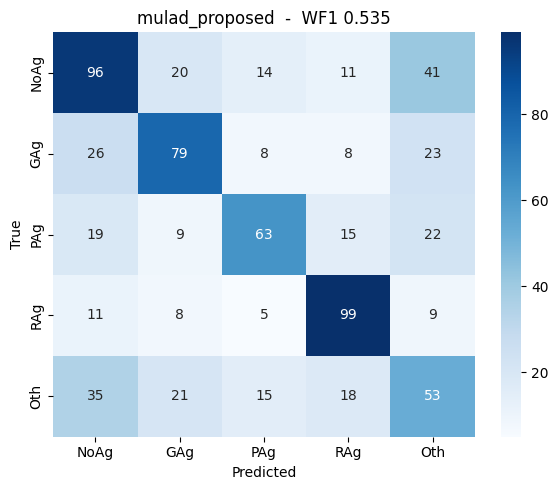

In [12]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

RUN = 'mulad_proposed'
r = json.load(open(ROOT + '/Outputs/results_' + RUN + '.json', encoding='utf-8'))
plt.figure(figsize=(6, 5))
sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=r['target_names'], yticklabels=r['target_names'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('%s  -  WF1 %.3f' % (RUN, r['weighted_f1']))
plt.tight_layout(); plt.show()

## 13. Save the outputs

`/kaggle/working` is wiped when the session ends. Commit the notebook, or download this
archive, before closing.

In [13]:
import shutil
shutil.make_archive('/kaggle/working/mulad_outputs', 'zip', ROOT + '/Outputs')
print('wrote /kaggle/working/mulad_outputs.zip')
print(sorted(os.listdir(ROOT + '/Outputs'))[:50])

wrote /kaggle/working/mulad_outputs.zip
['mulad_grid.csv', 'predictions_mulad_bilstm_cnn_resnet50_fasttext.csv', 'predictions_mulad_bilstm_cnn_resnet50_keras.csv', 'predictions_mulad_bilstm_cnn_resnet50_selftrained.csv', 'predictions_mulad_bilstm_cnn_vgg16_fasttext.csv', 'predictions_mulad_bilstm_cnn_vgg16_keras.csv', 'predictions_mulad_bilstm_cnn_vgg16_selftrained.csv', 'predictions_mulad_bilstm_cnn_vgg19_fasttext.csv', 'predictions_mulad_bilstm_cnn_vgg19_keras.csv', 'predictions_mulad_bilstm_cnn_vgg19_selftrained.csv', 'predictions_mulad_bilstm_resnet50_fasttext.csv', 'predictions_mulad_bilstm_resnet50_keras.csv', 'predictions_mulad_bilstm_resnet50_selftrained.csv', 'predictions_mulad_bilstm_vgg16_fasttext.csv', 'predictions_mulad_bilstm_vgg16_keras.csv', 'predictions_mulad_bilstm_vgg16_selftrained.csv', 'predictions_mulad_bilstm_vgg19_fasttext.csv', 'predictions_mulad_bilstm_vgg19_keras.csv', 'predictions_mulad_bilstm_vgg19_selftrained.csv', 'predictions_mulad_cnn_resnet50_fasttext.